# Прогнозирование стоимости подержанных автомобилей

**Задача.** Построить модель, которая по характеристикам автомобиля предсказывает цену объявления (регрессия, метрика — RMSE).

**План**
1. Загрузка и первичная очистка (цена, дубликаты)
2. Разбиение на train / valid / test (60 / 20 / 20)
3. EDA — только на train
4. Предобработка: один класс `DataPreprocess` внутри `Pipeline`
5. Подбор гиперпараметров по кросс-валидации на train, сравнение моделей на valid
6. Финальная проверка победителя на test (один раз), важность признаков
7. Выводы

**Принципы, на которых построена тетрадь**
- всё, что "обучается" на данных (медианы, кодирование по целевой переменной), считается только на train — внутри `Pipeline`;
- test используется один раз, для лучшей модели;
- все модели оформлены одинаково (`Pipeline` → `GridSearchCV`), код не дублируется.

## 1. Импорты и настройки

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')
%matplotlib inline

# ---- параметры, которые удобно менять в одном месте ----
RANDOM_STATE = 42
MIN_PRICE = 10                    # цены <= этого значения считаем ошибкой данных
DATA_YEAR = 2016                  # объявления выгружены в марте-апреле 2016
YEAR_MIN, YEAR_MAX = 1950, DATA_YEAR   # допустимый год регистрации
POWER_MIN, POWER_MAX = 1, 1000         # допустимая мощность, л.с.


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 2. Загрузка и первичная очистка

In [2]:
df = pd.read_csv('cars_price.csv')
print(df.shape)
df.head()

(8120, 16)


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-30 13:43:51,8691,other,1996,auto,176,NaN,150000,1,other,toyota,NaN,2016-03-30,0,86075,2016-04-05 13:54:03
1,2016-03-09 14:06:15,6906,NaN,2009,manual,58,3_reihe,150000,9,other,mazda,no,2016-03-09,0,27465,2016-03-15 11:04:42
2,2016-03-03 08:51:52,5510,sedan,2011,manual,162,qashqai,90000,7,petrol,nissan,yes,2016-03-03,0,82853,2016-03-06 20:51:14
3,2016-03-23 18:23:42,18918,sedan,2016,manual,190,s_klasse,100000,3,gasoline,mercedes_benz,no,2016-03-23,0,4151,2016-04-13 20:08:54
4,2016-03-17 03:29:43,11767,small,2008,manual,242,NaN,90000,10,NaN,mercedes_benz,no,2016-03-17,0,4412,2016-04-10 12:42:26


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8120 entries, 0 to 8119
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   DateCrawled        8120 non-null   str  
 1   Price              8120 non-null   int64
 2   VehicleType        7262 non-null   str  
 3   RegistrationYear   8120 non-null   int64
 4   Gearbox            7663 non-null   str  
 5   Power              8120 non-null   int64
 6   Model              7664 non-null   str  
 7   Kilometer          8120 non-null   int64
 8   RegistrationMonth  8120 non-null   int64
 9   FuelType           7366 non-null   str  
 10  Brand              8120 non-null   str  
 11  Repaired           6487 non-null   str  
 12  DateCreated        8120 non-null   str  
 13  NumberOfPictures   8120 non-null   int64
 14  PostalCode         8120 non-null   int64
 15  LastSeen           8120 non-null   str  
dtypes: int64(7), str(9)
memory usage: 1.6 MB


In [4]:
for col in ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']:
    print(col, df[col].unique(), '\n')

VehicleType <ArrowStringArray>
['other', nan, 'sedan', 'small', 'wagon', 'suv', 'coupe', 'bus',
 'convertible']
Length: 9, dtype: str 

Gearbox <ArrowStringArray>
['auto', 'manual', nan]
Length: 3, dtype: str 

Model <ArrowStringArray>
[          nan,     '3_reihe',     'qashqai',    's_klasse',         '500',
     '6_reihe',    'berlingo',       'punto',       'yaris',    'c_klasse',
     'x_reihe',      'mondeo',     '2_reihe',     'corolla',      'fortwo',
       'corsa',          'a1',     'forfour',        'leon',         'v70',
      'cooper',    'e_klasse',      'fiesta',       'micra',          'a3',
         '3er',     'avensis',         '7er',       'panda',         'v40',
     'clubman',     'octavia',       'ibiza',    'a_klasse',          'ka',
          'c3',      'andere',      'tiguan',        'golf',       'fabia',
      'zafira',     '5_reihe',       'astra',      'passat',    'insignia',
        'polo',        'note',          'a4', 'transporter',          'c4',
    

### Цена

Смотрим на распределение цены (логарифмическая шкала), чтобы обосновать порог `MIN_PRICE`, а не выбирать его "на глаз".

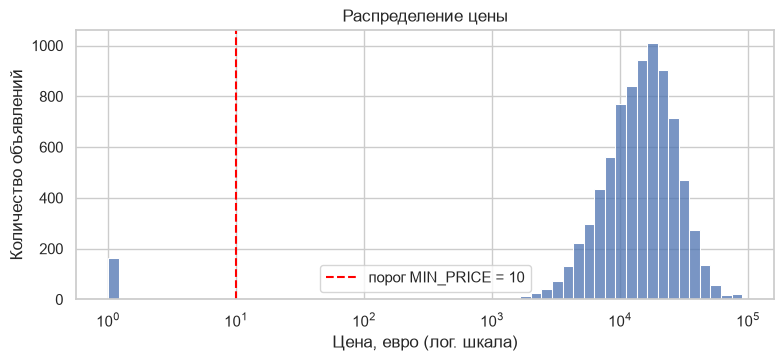

Цен <= порога: 163


In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(df['Price'].clip(lower=1), log_scale=True, bins=60, ax=ax)
ax.axvline(MIN_PRICE, color='red', ls='--', label=f'порог MIN_PRICE = {MIN_PRICE}')
ax.set_xlabel('Цена, евро (лог. шкала)')
ax.set_ylabel('Количество объявлений')
ax.set_title('Распределение цены')
ax.legend()
plt.show()

print('Цен <= порога:', (df['Price'] <= MIN_PRICE).sum())

In [6]:
# Удаляем нереалистичные цены и полные дубликаты ДО разбиения,
# чтобы одинаковые объявления не попали одновременно в train и test.
n_start = len(df)
df_clean = df[df['Price'] > MIN_PRICE]
n_after_price = len(df_clean)
df_clean = df_clean.drop_duplicates()

print(f'Исходно:               {n_start}')
print(f'Удалено по цене:       {n_start - n_after_price}')
print(f'Удалено дубликатов:    {n_after_price - len(df_clean)}')
print(f'Осталось:              {len(df_clean)}')

Исходно:               8120
Удалено по цене:       163
Удалено дубликатов:    58
Осталось:              7899


## 3. Разбиение на выборки

60 % — train (обучение и подбор параметров по кросс-валидации), 20 % — valid (выбор лучшей модели), 20 % — test (финальная проверка, один раз).

In [7]:
X = df_clean.drop(columns='Price')
y = df_clean['Price']

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_valid, X_test, y_valid, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE)

print(f'train: {X_train.shape}, valid: {X_valid.shape}, test: {X_test.shape}')

train: (4739, 15), valid: (1580, 15), test: (1580, 15)


## 4. EDA (только train)

Все графики строим по обучающей выборке: valid и test мы "не видим".

In [8]:
eda = X_train.assign(Price=y_train)
eda.describe()

,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode,Price
count,4739.000000,4739.000000,4739.000000,4739.000000,4739.0,4739.000000,4739.000000
mean,2005.034184,150.605191,108768.727580,5.975522,0.0,50702.496518,17245.688753
std,38.129139,265.820663,44120.409053,3.718321,0.0,28481.198743,10723.593098
min,1000.000000,0.000000,5000.000000,0.000000,0.0,1010.000000,1345.000000
25%,2000.000000,90.000000,80000.000000,3.000000,0.0,26045.000000,9637.500000
50%,2005.000000,146.000000,125000.000000,6.000000,0.0,50949.000000,15136.000000
75%,2011.000000,200.500000,150000.000000,9.000000,0.0,75450.000000,22212.000000
max,2800.000000,16112.000000,150000.000000,12.000000,0.0,99969.000000,90000.000000


In [9]:
eda.describe(include=['object', 'string'])

,DateCrawled,VehicleType,Gearbox,Model,FuelType,Brand,Repaired,DateCreated,LastSeen
count,4739,4247,4494,4461,4295,4739,3763,4739,4739
unique,4736,8,2,66,7,20,2,40,4736
top,2016-03-15 03:28:58,sedan,manual,andere,gasoline,hyundai,no,2016-03-19,2016-03-24 07:16:52
freq,2,858,3346,193,1710,270,3216,138,2


### 4.1 Аномалии в числовых признаках

In [10]:
anomalies = pd.Series({
    f'RegistrationYear < {YEAR_MIN}': (eda['RegistrationYear'] < YEAR_MIN).sum(),
    f'RegistrationYear > {YEAR_MAX} (позже даты выгрузки)': (eda['RegistrationYear'] > YEAR_MAX).sum(),
    'Power == 0': (eda['Power'] == 0).sum(),
    f'Power > {POWER_MAX}': (eda['Power'] > POWER_MAX).sum(),
}, name='количество строк')
anomalies.to_frame()

,количество строк
RegistrationYear < 1950,10
RegistrationYear > 2016 (позже даты выгрузки),6
Power == 0,145
Power > 1000,4


In [11]:
# Годы 1000 / 9999 и мощность 16214 л.с. — явные ошибки ввода.
# Цена у таких объявлений обычная, значит признак испорчен, а не автомобиль "раритетный".
eda[(eda['RegistrationYear'] < YEAR_MIN) | (eda['RegistrationYear'] > YEAR_MAX)][
    ['Price', 'Brand', 'Model', 'RegistrationYear', 'Power']
].head(10)

,Price,Brand,Model,RegistrationYear,Power
5084,39692,audi,a4,1000,166
2260,25172,bmw,3er,1900,206
855,8162,nissan,qashqai,2800,65
5357,10688,renault,clio,1900,173
6255,14494,volvo,v70,1000,173
3748,16570,opel,zafira,2800,78
2035,10304,audi,a1,1800,78
8079,23098,renault,megane,1000,208
7006,14619,fiat,panda,1900,172
2479,13161,volkswagen,touran,2800,174


### 4.2 Числовые признаки и цена (по допустимым значениям)

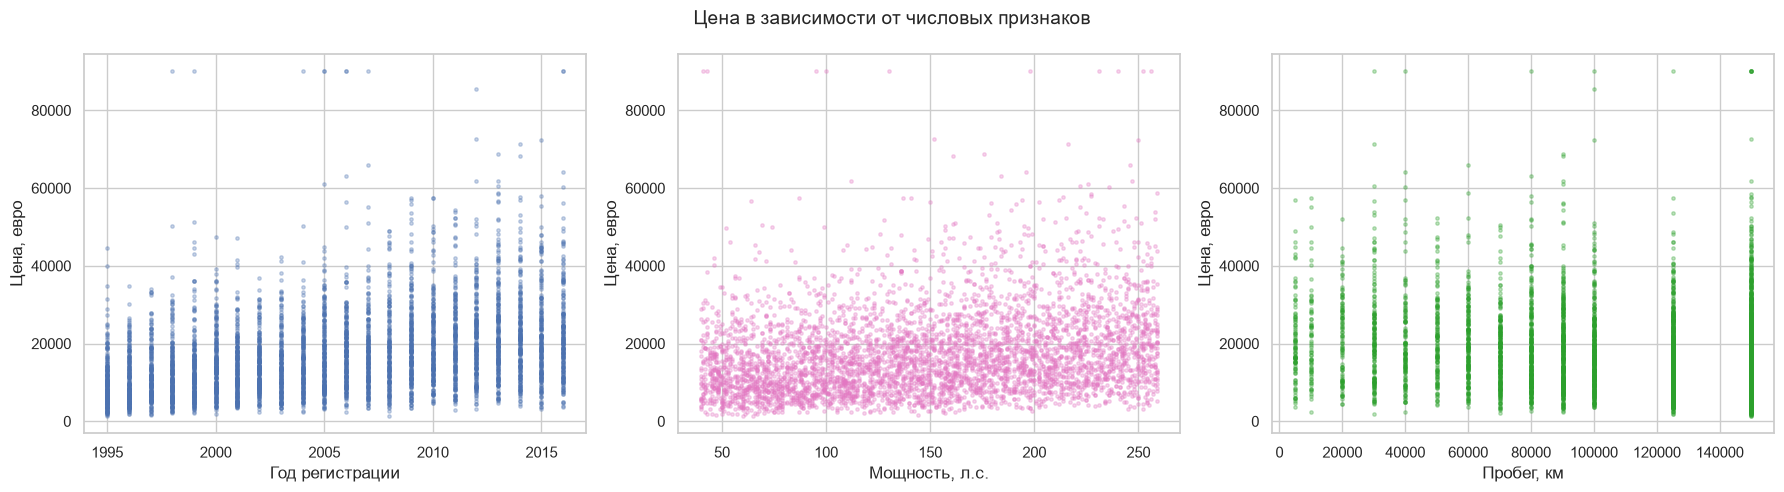

In [12]:
ok_year = eda['RegistrationYear'].between(YEAR_MIN, YEAR_MAX)
ok_power = eda['Power'].between(POWER_MIN, POWER_MAX)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(eda.loc[ok_year, 'RegistrationYear'], eda.loc[ok_year, 'Price'], s=6, alpha=0.3)
axes[0].set_xlabel('Год регистрации')
axes[1].scatter(eda.loc[ok_power, 'Power'], eda.loc[ok_power, 'Price'], s=6, alpha=0.3, color='tab:pink')
axes[1].set_xlabel('Мощность, л.с.')
axes[2].scatter(eda['Kilometer'], eda['Price'], s=6, alpha=0.3, color='tab:green')
axes[2].set_xlabel('Пробег, км')
for ax in axes:
    ax.set_ylabel('Цена, евро')
fig.suptitle('Цена в зависимости от числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Категориальные признаки и цена

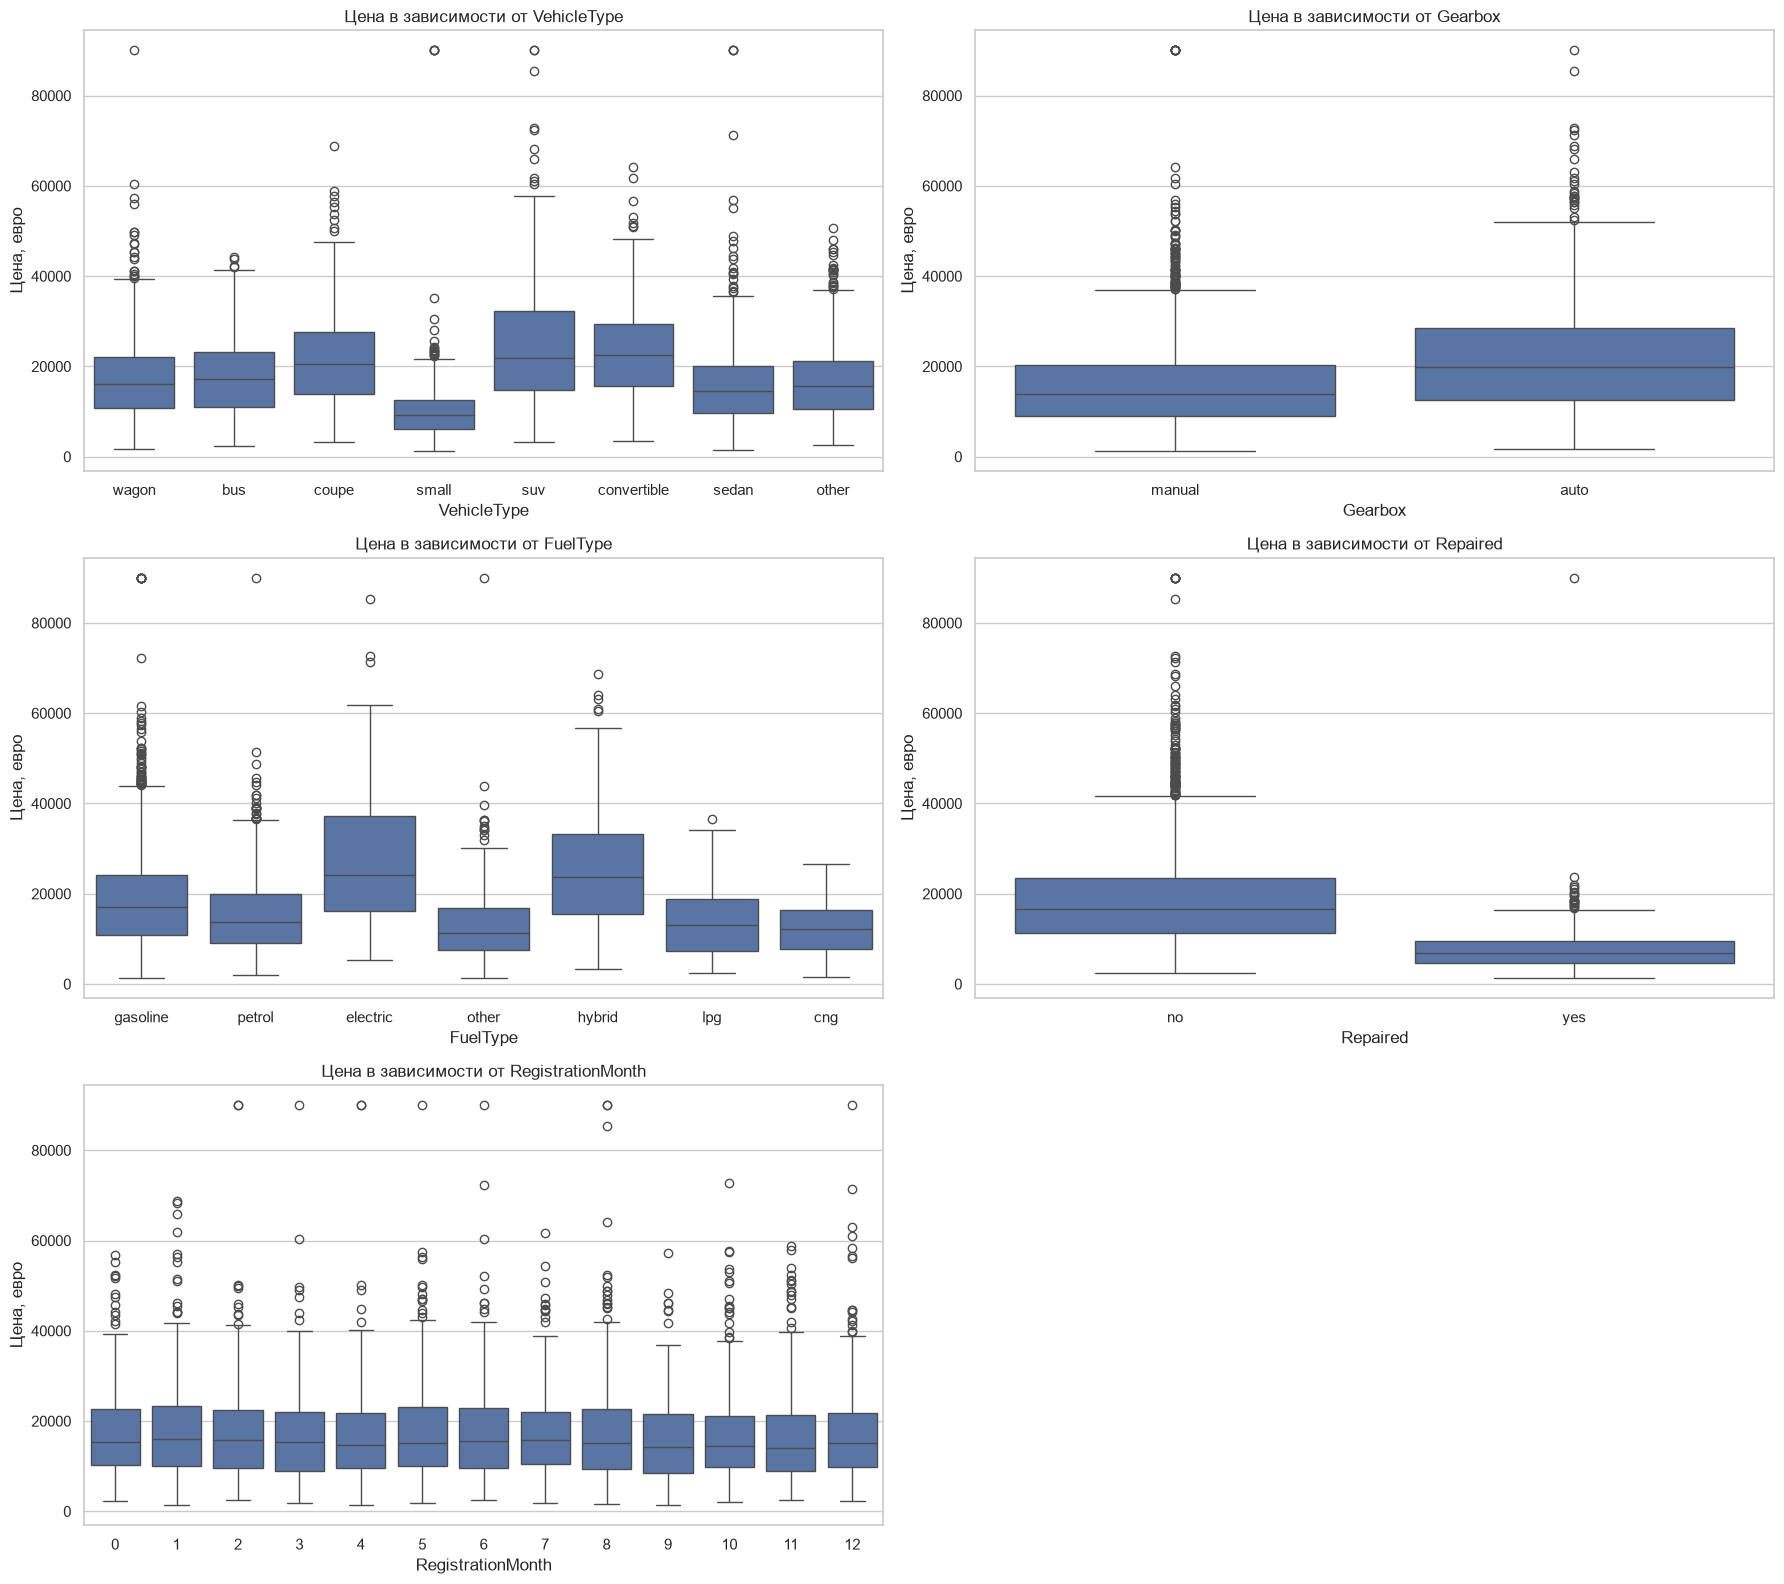

In [13]:
cat_for_box = ['VehicleType', 'Gearbox', 'FuelType', 'Repaired', 'RegistrationMonth']
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.ravel()
for ax, col in zip(axes, cat_for_box):
    sns.boxplot(data=eda, x=col, y='Price', ax=ax)
    ax.set_ylabel('Цена, евро')
    ax.set_title(f'Цена в зависимости от {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

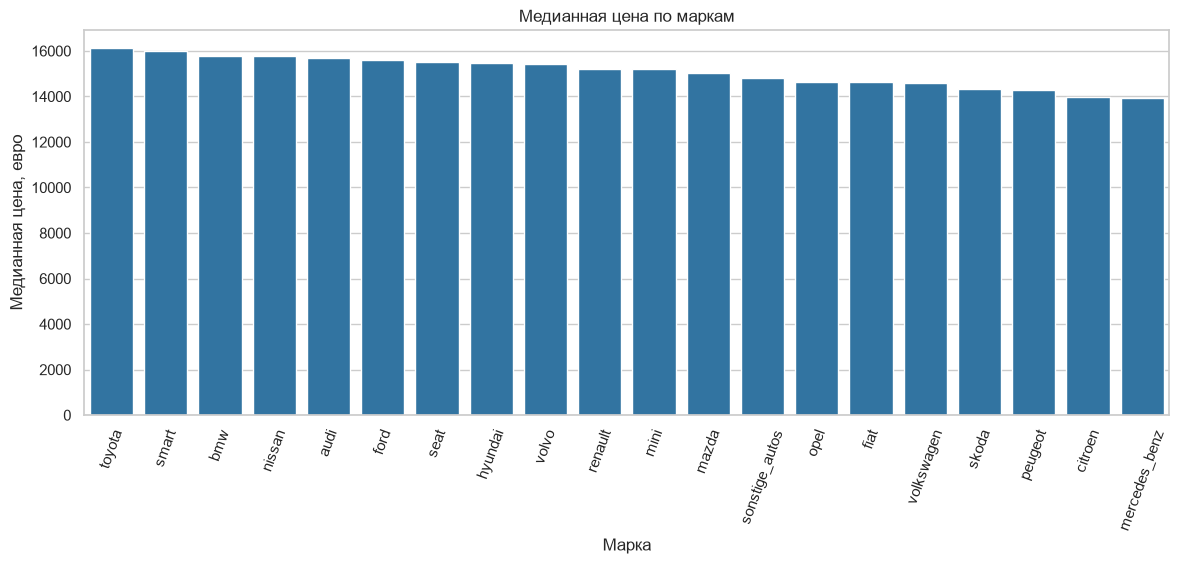

In [14]:
brand_median = eda.groupby('Brand')['Price'].median().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(x=brand_median.index, y=brand_median.values, color='tab:blue')
plt.xticks(rotation=70)
plt.title('Медианная цена по маркам')
plt.ylabel('Медианная цена, евро')
plt.xlabel('Марка')
plt.show()

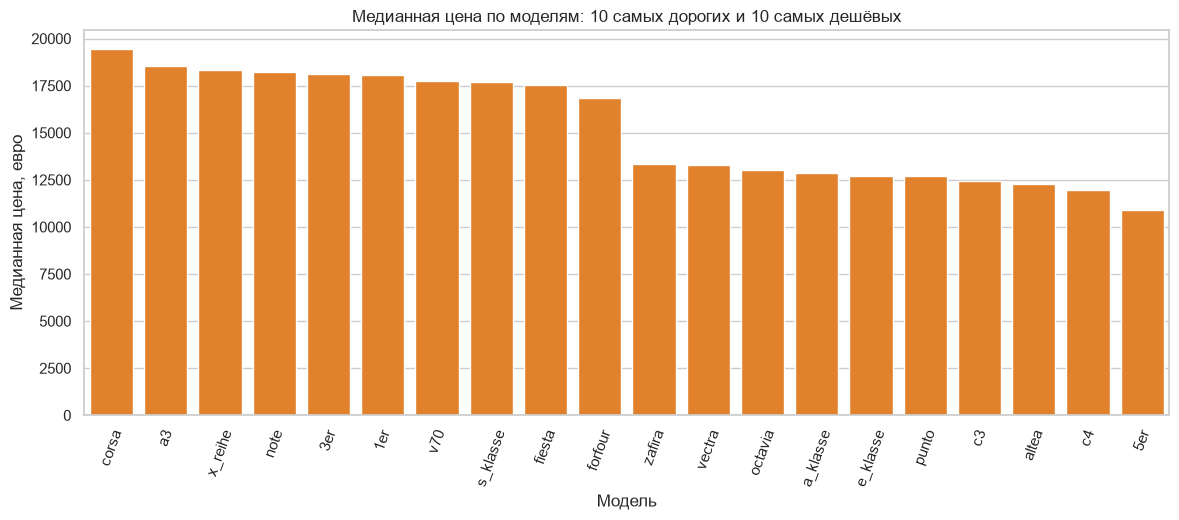

In [15]:
# Модели: берём только те, у которых хватает объявлений (>= 10), и показываем 10 самых дорогих и 10 самых дешёвых.
model_stat = eda.groupby('Model')['Price'].agg(['median', 'count'])
model_stat = model_stat[model_stat['count'] >= 10].sort_values('median', ascending=False)
model_plot = pd.concat([model_stat.head(10), model_stat.tail(10)])

plt.figure(figsize=(14, 5))
sns.barplot(x=model_plot.index, y=model_plot['median'], color='tab:orange')
plt.xticks(rotation=70)
plt.title('Медианная цена по моделям: 10 самых дорогих и 10 самых дешёвых')
plt.ylabel('Медианная цена, евро')
plt.xlabel('Модель')
plt.show()

### 4.4 Пропуски

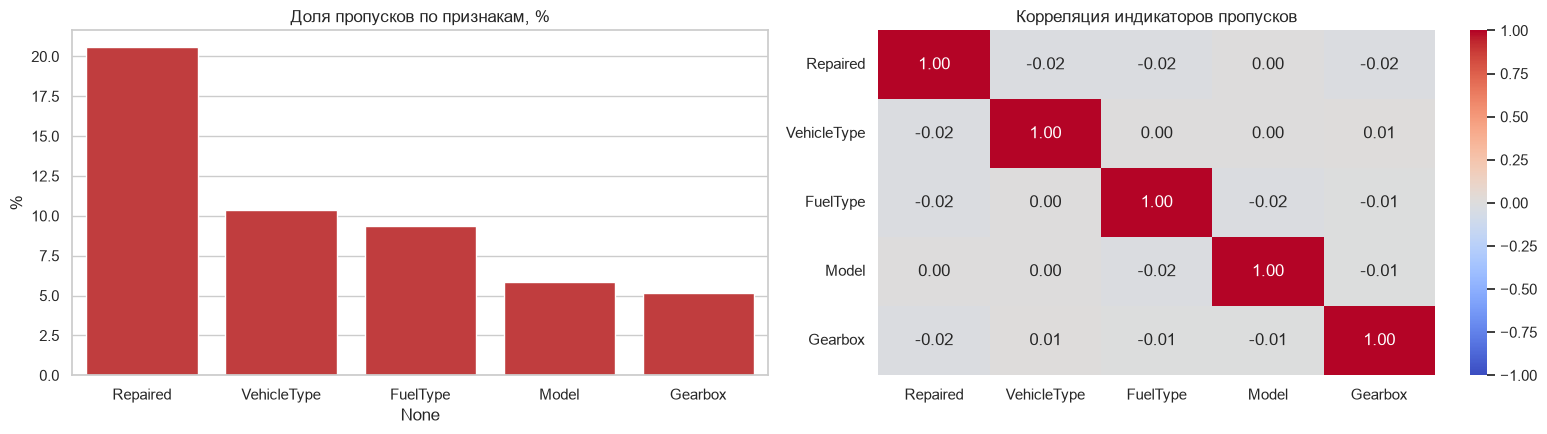

In [16]:
na_share = eda.isna().mean()
na_share = na_share[na_share > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

sns.barplot(x=na_share.index, y=na_share.values * 100, color='tab:red', ax=axes[0])
axes[0].set_title('Доля пропусков по признакам, %')
axes[0].set_ylabel('%')

na_cols = list(na_share.index)
sns.heatmap(eda[na_cols].isna().corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Корреляция индикаторов пропусков')
plt.tight_layout()
plt.show()

### Выводы по EDA

- **Год регистрации** содержит невозможные значения (1000…9999), а также годы позже даты выгрузки (2016). **Мощность** — нули и значения вплоть до 16 214 л.с. Это ошибки данных: на цене они не отражаются, поэтому в предобработке их превращаем в пропуски и заполняем медианой **по train**.
- Пропуски есть только в категориальных признаках, больше всего в `Repaired` (около 20 % строк).
- Индикаторы пропусков почти не коррелируют друг с другом (|r| < 0.03): пропуски не "приходят пачками", а разбросаны независимо. Значит, строки с несколькими пропусками не являются особым классом объявлений, и удалять их нет явных оснований — проверим это экспериментом ниже.
- В `Model` есть значения `andere` и (после заполнения пропусков) `other` — это одно и то же ("модель не указана"), объединяем.
- Служебные столбцы (`DateCrawled`, `DateCreated`, `LastSeen`, `NumberOfPictures`) для прогноза цены не нужны. `RegistrationMonth` на boxplot-е не показывает выраженной связи с ценой, поэтому тоже не используется (при желании его можно вернуть в `NUM_COLS` и проверить на valid).

## 5. Предобработка

Один класс `DataPreprocess` делает всё:

1. **Без обучения** (нет утечки): оставляет нужные столбцы, превращает невозможные год/мощность в пропуски, берёт регион из первых цифр индекса, заполняет пропуски в категориях, объединяет `andere` → `other`.
2. **С обучением на train** (`fit`): медианы года и мощности; для `encoding=True` — порядковое кодирование категорий по средней цене (чем дороже категория, тем меньше номер). Редкие категории (меньше `min_count` объявлений) объединяются в `rare`, чтобы средняя цена по 1–2 объявлениям не давала случайный порядок.
3. `encoding=False` оставляет категории строками — это нужно CatBoost, у которого собственная работа с категориальными признаками.

Класс кладём **внутрь `Pipeline`**: при кросс-валидации он переобучается на каждом обучающем фолде, а значит, средние цены по категориям никогда не "подглядывают" в проверочный фолд.

> В прошлой версии один и тот же объект `data_preprocess` стоял сразу в нескольких пайплайнах. `Pipeline` не копирует свои шаги, поэтому повторный `fit` одного пайплайна менял состояние всех остальных. Здесь пайплайны собирает функция `make_pipeline` — каждый раз из новых объектов.

In [17]:
NUM_COLS = ['RegistrationYear', 'Power', 'Kilometer', 'PostalCode']
CAT_COLS = ['Brand', 'Model', 'VehicleType', 'FuelType', 'Gearbox', 'Repaired']
FEATURES = NUM_COLS + CAT_COLS


class DataPreprocess(BaseEstimator, TransformerMixin):

    FILL_VALUES = {
        'Model': 'other',
        'VehicleType': 'unknown',
        'Gearbox': 'unknown',
        'FuelType': 'unknown',
        'Repaired': 'unknown',
    }

    def __init__(self, encoding=True, min_count=5):
        self.encoding = encoding
        self.min_count = min_count

    def _clean(self, X):
        # преобразования без обучения: никакой статистики по данным здесь нет
        X = X[FEATURES].copy()
        X['RegistrationYear'] = X['RegistrationYear'].where(X['RegistrationYear'].between(YEAR_MIN, YEAR_MAX))
        X['Power'] = X['Power'].where(X['Power'].between(POWER_MIN, POWER_MAX))
        X['PostalCode'] = X['PostalCode'] // 1000
        X = X.fillna(self.FILL_VALUES)
        X['Model'] = X['Model'].replace('andere', 'other')
        return X

    def fit(self, X, y=None):
        X = self._clean(X)
        # медианы — только по train
        self.medians_ = {col: X[col].median() for col in ['RegistrationYear', 'Power']}

        if self.encoding:
            y = pd.Series(np.asarray(y), index=X.index)
            self.frequent_, self.rank_dicts_ = {}, {}
            for col in CAT_COLS:
                counts = X[col].value_counts()
                frequent = set(counts[counts >= self.min_count].index)
                grouped = X[col].where(X[col].isin(frequent), 'rare')
                order = y.groupby(grouped).mean().sort_values(ascending=False).index
                self.frequent_[col] = frequent
                self.rank_dicts_[col] = {cat: rank for rank, cat in enumerate(order)}
        return self

    def transform(self, X):
        X = self._clean(X)
        for col, median in self.medians_.items():
            X[col] = X[col].fillna(median)

        if self.encoding:
            for col in CAT_COLS:
                ranks = self.rank_dicts_[col]
                grouped = X[col].where(X[col].isin(self.frequent_[col]), 'rare')
                # категории, которых не было в train, получают "последний" ранг
                X[col] = grouped.map(ranks).fillna(len(ranks)).astype(int)
        return X


def make_pipeline(model, encoding=True):
    # каждый вызов создаёт НОВЫЙ препроцессор: пайплайны не делят состояние
    return Pipeline([('prep', DataPreprocess(encoding=encoding)), ('model', model)])

In [18]:
# быстрая проверка препроцессора на train
check = DataPreprocess().fit_transform(X_train, y_train)
print(check.isna().sum().sum(), 'пропусков после обработки')
check.describe().T[['min', 'max']]

0 пропусков после обработки


,min,max
RegistrationYear,1995.0,2016.0
Power,40.0,259.0
Kilometer,5000.0,150000.0
PostalCode,1.0,99.0
Brand,0.0,19.0
Model,0.0,65.0
VehicleType,0.0,8.0
FuelType,0.0,7.0
Gearbox,0.0,2.0
Repaired,0.0,2.0


### Эксперимент: удалять ли строки с несколькими пропусками?

Раньше из train удалялись строки с двумя и более пропусками, при этом valid/test оставались как есть — то есть модель училась на данных, устроенных иначе, чем те, на которых её проверяют. Сравним оба варианта на одной и той же модели и одной и той же valid-выборке.

In [19]:
quick = make_pipeline(LGBMRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05,
                                    num_leaves=31, n_jobs=1, verbose=-1))

na_cols_cat = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Repaired']
n_missing = X_train[na_cols_cat].isna().sum(axis=1)

rows = []
for label, mask in {'все строки': n_missing >= 0, 'без строк с >= 2 пропусками': n_missing < 2}.items():
    m = clone(quick).fit(X_train[mask], y_train[mask])
    rows.append({'вариант': label, 'строк в train': int(mask.sum()), 'RMSE valid': rmse(y_valid, m.predict(X_valid))})
pd.DataFrame(rows).set_index('вариант').round(2)

,строк в train,RMSE valid
вариант,,
все строки,4739,5454.32
без строк с >= 2 пропусками,4373,5480.76


Разница в сотню-две евро на одной valid-выборке из ~1,5 тыс. строк — в пределах шума. Если "все строки" не хуже, оставляем их: меньше правил, и обучающая выборка похожа на реальные данные. Если вариант с удалением заметно лучше, его можно вернуть, но тогда стоит проверить это и кросс-валидацией.

## 6. Модели

**Baseline.** Прежде чем сравнивать модели друг с другом, нужна точка отсчёта: предсказание средней цены. Любая модель должна быть заметно лучше.

**Подбор параметров.** `GridSearchCV` с 5-кратной кросс-валидацией на train. Кросс-валидация надёжнее одной valid-выборки (на 1,5 тыс. строк разница между моделями легко тонет в шуме) и заодно честно переобучает кодирование внутри каждого фолда.

Сетки сделаны шире прежних: раньше лучшее значение почти везде оказывалось на краю сетки (`max_depth` у решающего дерева и XGBoost, `n_estimators` у XGBoost, `learning_rate` и `num_leaves` у LightGBM) — значит, оптимум мог лежать за её пределами.

Каждая модель использует один поток (`n_jobs=1` / `thread_count=1`), а параллелится сам `GridSearchCV`: так нет борьбы за ядра, а время обучения у разных моделей сопоставимо.

In [20]:
models = {
    'DecisionTree': (
        make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
        {'model__max_depth': [4, 6, 8, 10, 12, 15, None],
         'model__min_samples_leaf': [1, 5, 20]},
    ),
    'RandomForest': (
        make_pipeline(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1)),
        {'model__max_depth': [8, 12, 16, None],
         'model__min_samples_leaf': [1, 3, 5]},
    ),
    'XGBoost': (
        make_pipeline(XGBRegressor(random_state=RANDOM_STATE, n_jobs=1)),
        {'model__learning_rate': [0.03, 0.1, 0.2],
         'model__n_estimators': [200, 400],
         'model__max_depth': [2, 3, 4, 6]},
    ),
    'LightGBM': (
        make_pipeline(LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1)),
        {'model__learning_rate': [0.03, 0.05, 0.1],
         'model__n_estimators': [200, 400],
         'model__num_leaves': [15, 31, 63, 100]},
    ),
    'CatBoost': (
        make_pipeline(
            CatBoostRegressor(random_seed=RANDOM_STATE, iterations=400, verbose=False, thread_count=1,
                              allow_writing_files=False),
            encoding=False,   # CatBoost сам кодирует категории
        ),
        {'model__learning_rate': [0.05, 0.1, 0.2],
         'model__depth': [4, 6, 8]},
    ),
}

# CatBoost нужно сообщить, какие столбцы категориальные. Через параметр конструктора это ломает sklearn.clone,
# поэтому передаём список в fit (формат "<шаг пайплайна>__<параметр>").
FIT_PARAMS = {'CatBoost': {'model__cat_features': CAT_COLS}}

In [21]:
%%time
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- baseline ---
baseline = DummyRegressor(strategy='mean').fit(X_train, y_train)
results = [{
    'Модель': 'Baseline (средняя цена)',
    'RMSE cv (train)': np.nan,
    'RMSE valid': rmse(y_valid, baseline.predict(X_valid)),
    'Обучение, сек': 0.0,
    'Предсказание, сек': 0.0,
    'Параметры': '-',
}]

# --- модели ---
searches = {}
for name, (pipe, grid) in models.items():
    start = time.time()
    search = GridSearchCV(pipe, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    search.fit(X_train, y_train, **FIT_PARAMS.get(name, {}))

    t0 = time.time()
    valid_pred = search.predict(X_valid)
    predict_time = time.time() - t0

    searches[name] = search
    results.append({
        'Модель': name,
        'RMSE cv (train)': -search.best_score_,
        'RMSE valid': rmse(y_valid, valid_pred),
        'Обучение, сек': search.refit_time_,      # время обучения лучшей конфигурации на всём train (включая предобработку)
        'Предсказание, сек': predict_time,
        'Параметры': {k.replace('model__', ''): v for k, v in search.best_params_.items()},
    })
    print(f'{name:13s} готово за {time.time() - start:6.1f} сек')

DecisionTree  готово за    4.4 сек
RandomForest  готово за    9.9 сек
XGBoost       готово за    2.8 сек
LightGBM      готово за    3.3 сек
CatBoost      готово за   54.1 сек
CPU times: total: 13.9 s
Wall time: 1min 14s


In [22]:
results_table = pd.DataFrame(results).set_index('Модель').sort_values('RMSE valid')
results_table.round({'RMSE cv (train)': 1, 'RMSE valid': 1, 'Обучение, сек': 2, 'Предсказание, сек': 3})

,RMSE cv (train),RMSE valid,"Обучение, сек","Предсказание, сек",Параметры
Модель,,,,,
CatBoost,5605.6,5159.6,8.79,0.018,"{'depth': 6, 'learning_rate': 0.05}"
LightGBM,5723.6,5318.1,0.11,0.020,"{'learning_rate': 0.05, 'n_estimators': 200, '..."
XGBoost,5783.3,5368.2,0.36,0.017,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est..."
RandomForest,6052.8,5662.2,1.74,0.047,"{'max_depth': None, 'min_samples_leaf': 5}"
DecisionTree,6914.1,6531.1,0.05,0.014,"{'max_depth': 10, 'min_samples_leaf': 20}"
Baseline (средняя цена),NaN,10798.2,0.00,0.000,-


**Как читать таблицу.** `RMSE cv` — средняя ошибка по 5 фолдам train (по ней выбраны параметры), `RMSE valid` — ошибка на отложенной выборке (по ней выбираем модель). Если у модели `cv` и `valid` близки — результат устойчив; если сильно расходятся, valid-оценка шумная.

Если у лучших параметров значение снова на границе сетки (смотрите колонку «Параметры»), сетку стоит расширить в ту сторону.

## 7. Финальная проверка на test

Победителя выбираем по `RMSE valid` (с оглядкой на `RMSE cv`). Затем переобучаем его с найденными параметрами на **train + valid** и один раз считаем ошибку на test. Остальные модели на test не смотрим — иначе test превращается в ещё одну валидационную выборку.

In [23]:
best_name = results_table.drop(index='Baseline (средняя цена)').index[0]
best_search = searches[best_name]

X_trainval = pd.concat([X_train, X_valid])
y_trainval = pd.concat([y_train, y_valid])

final_model = clone(best_search.best_estimator_).fit(X_trainval, y_trainval, **FIT_PARAMS.get(best_name, {}))
rmse_test = rmse(y_test, final_model.predict(X_test))

baseline_final = DummyRegressor(strategy='mean').fit(X_trainval, y_trainval)
rmse_test_baseline = rmse(y_test, baseline_final.predict(X_test))

print(f'Лучшая модель:                 {best_name}')
print(f'Параметры:                     {results_table.loc[best_name, "Параметры"]}')
print(f'RMSE на valid:                 {results_table.loc[best_name, "RMSE valid"]:.1f}')
print(f'RMSE на test:                  {rmse_test:.1f}')
print(f'RMSE baseline на test:         {rmse_test_baseline:.1f}')
print(f'Улучшение относительно baseline: {(1 - rmse_test / rmse_test_baseline) * 100:.0f} %')

Лучшая модель:                 CatBoost
Параметры:                     {'depth': 6, 'learning_rate': 0.05}
RMSE на valid:                 5159.6
RMSE на test:                  5346.9
RMSE baseline на test:         10636.7
Улучшение относительно baseline: 50 %


### Важность признаков

Используем **permutation importance** на valid: насколько вырастает RMSE, если перемешать значения одного признака. В отличие от встроенной важности деревьев, она не завышает признаки с большим числом уникальных значений (например, `Model`) и работает для любой модели из пайплайна. Считаем для лучшей модели (а не случайно выбранной).

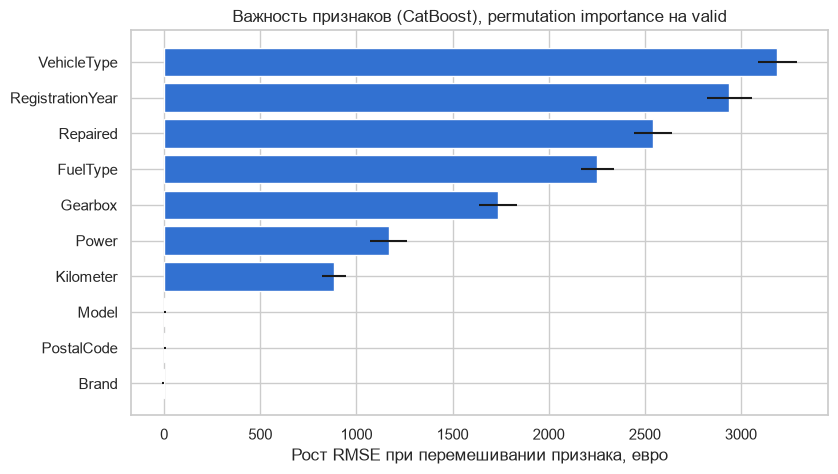

In [24]:
perm = permutation_importance(best_search.best_estimator_, X_valid[FEATURES], y_valid,
                              scoring='neg_root_mean_squared_error',
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)

imp = (pd.DataFrame({'mean': perm.importances_mean, 'std': perm.importances_std}, index=FEATURES)
         .sort_values('mean'))

plt.figure(figsize=(9, 5))
plt.barh(imp.index, imp['mean'], xerr=imp['std'], color='#3271D1')
plt.title(f'Важность признаков ({best_name}), permutation importance на valid')
plt.xlabel('Рост RMSE при перемешивании признака, евро')
plt.show()

## 8. Выводы

In [25]:
print(f'Лучшая модель — {best_name}: RMSE на test = {rmse_test:.0f} евро '
      f'(baseline "средняя цена" — {rmse_test_baseline:.0f} евро).')
print('Самые важные признаки:', ', '.join(imp.sort_values('mean', ascending=False).index[:3]))

Лучшая модель — CatBoost: RMSE на test = 5347 евро (baseline "средняя цена" — 10637 евро).
Самые важные признаки: VehicleType, RegistrationYear, Repaired


Заполните после запуска:

- какая модель победила и насколько она лучше baseline и остальных (с учётом того, что разница меньше ~100–200 евро — в пределах шума);
- какие признаки важнее всего и согласуется ли это с EDA;
- что дальше: логарифм целевой переменной, новые признаки (возраст авто, пара «марка + модель»), более широкий поиск параметров (`RandomizedSearchCV` / Optuna).